In [2]:
!pip install scikit-learn matplotlib



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [3]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
import numpy as np
import seaborn as sns

In [4]:
df=pd.read_csv('train.csv')  # Load your dataset
test_df=pd.read_csv('test.csv')# Load your dataset

In [5]:
text_col = "catalog_content"

In [6]:
# 2️⃣ Extract simple numeric features
def make_features(s):
    s = s.fillna("").astype(str)
    return np.vstack([
        s.str.len().values,           # text length
        s.str.split().map(len).values, # word count
        s.str.count(r"\d").values,    # number of digits
        s.str.count(",").values,      # commas
        s.str.count("\.").values      # periods
    ]).T

X_train_features = make_features(df[text_col])
X_test_features = make_features(test_df[text_col])

# Add sample_id as numeric
X_train_features = np.hstack([X_train_features, df["sample_id"].values.reshape(-1, 1)])
X_test_features = np.hstack([X_test_features, test_df["sample_id"].values.reshape(-1, 1)])

# Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_features)
X_test_scaled = scaler.transform(X_test_features)


<>:9: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<>:9: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
/var/folders/hg/6k2xrn0x1hxd4zlz_g32w19h0000gn/T/ipykernel_30216/3604314109.py:9: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
  s.str.count("\.").values      # periods


In [7]:
# 1️⃣ Apply PCA to reduce data to 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_scaled)

# Add PCA results to DataFrame for plotting
df["pca_1"] = X_pca[:, 0]
df["pca_2"] = X_pca[:, 1]

print(f"Explained variance by 2 components: {pca.explained_variance_ratio_.sum():.2%}")
df.head()


Explained variance by 2 components: 80.95%


,sample_id,catalog_content,image_link,price,pca_1,pca_2
0,33127,"Item Name: La Victoria Green Taco Sauce Mild, ...",https://m.media-amazon.com/images/I/51mo8htwTH...,4.89,-1.923069,-1.394690
1,198967,"Item Name: Salerno Cookies, The Original Butte...",https://m.media-amazon.com/images/I/71YtriIHAA...,13.12,-0.954193,0.548231
2,261251,"Item Name: Bear Creek Hearty Soup Bowl, Creamy...",https://m.media-amazon.com/images/I/51+PFEe-w-...,1.97,-1.369582,1.247980
3,55858,Item Name: Judee’s Blue Cheese Powder 11.25 oz...,https://m.media-amazon.com/images/I/41mu0HAToD...,30.34,0.921511,-1.055934
4,292686,"Item Name: kedem Sherry Cooking Wine, 12.7 Oun...",https://m.media-amazon.com/images/I/41sA037+Qv...,66.49,-1.370218,1.597826


In [9]:
print(df.columns)

Index(['sample_id', 'catalog_content', 'image_link', 'price', 'pca_1',
       'pca_2'],
      dtype='object')


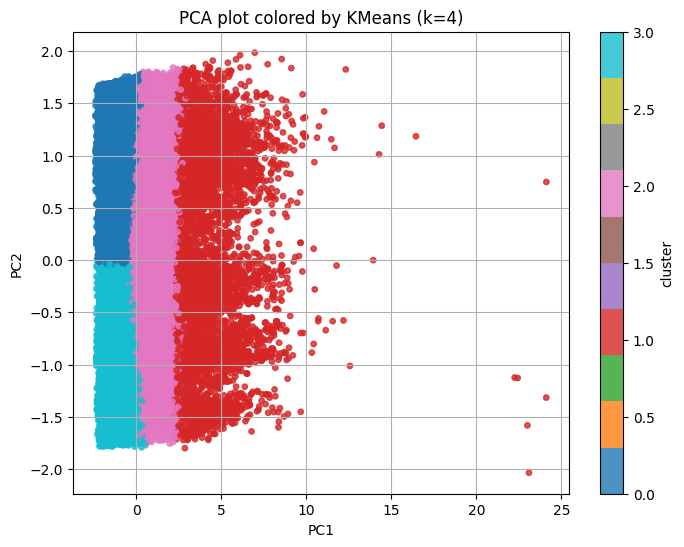

In [10]:
from sklearn.cluster import KMeans

# choose k (change if you prefer)
K = 4

# fit on the same scaled features you used for PCA (X_train_scaled)
# if you used X_train_scaled when building PCA use that; otherwise rebuild features first
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_train_scaled)   # <-- use the same X used for PCA
# if you want clusters for test as well: test_df['cluster'] = kmeans.predict(X_test_scaled)

# now plot
plt.figure(figsize=(8,6))
plt.scatter(df["pca_1"], df["pca_2"], c=df["cluster"], cmap="tab10", s=15, alpha=0.8)
plt.title(f"PCA plot colored by KMeans (k={K})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="cluster")
plt.grid(True)
plt.show()



In [11]:
# 4️⃣ Save the 2D PCA features with clusters
df[["sample_id", "pca_1", "pca_2", "cluster"]].to_csv("pca_cluster_visualization.csv", index=False)
print("💾 Saved PCA visualization data to 'pca_cluster_visualization.csv'")


💾 Saved PCA visualization data to 'pca_cluster_visualization.csv'
